In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import requests
from io import StringIO
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os
# dependency on pyarrow -> include in toml

1. Universe Selection
2. Factor Exploration
3. Factor Model Decomposition
4. Portfolio Risk Decomposition

# Universe Selection
Selecting the most liquid stocks

In [29]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
response.raise_for_status()

sp500 = pd.read_html(StringIO(response.text))[0]
sp500tickers = sp500['Symbol'].tolist()
sp500tickers = [t.replace('.', '-') for t in sp500tickers] # Cleaning tickers, some of them have dots instead of dashes

In [30]:
def get_prices(tickers, start, end, path):
    folder = os.path.dirname(path)
    
    if folder:
        os.makedirs(folder, exist_ok= True)
        
    if os.path.exists(path):
        return pd.read_parquet(path)
    
    data = yf.download(tickers, start = start, end = end)
    data.to_parquet(path)
    return data

In [31]:
start = "2015-01-01"
end = "2025-01-01"
liquidity_check = get_prices(sp500tickers, start, end, path = "SP500.parquet")

In [32]:
avg_volume = liquidity_check['Volume'].mean(axis = 0).sort_values(ascending = False)
top30 = avg_volume[:30]
top30_tickers = top30.index.tolist()

# Factor Exploration

In [33]:
# Fama French 3 Factors Daily
path = "F-F_Research_Data_Factors_daily.csv"
factors = pd.read_csv(path)
factors["Date"] = pd.to_datetime(factors["Date"], format="%Y%m%d")
factors.set_index("Date", inplace=True)
cols = ["Mkt-RF", "SMB", "HML","RF"]
factors[cols] /= 100 # Rescaling factors

# Factor Model Estimation

In [34]:
financials = liquidity_check.loc[:, (slice(None), top30_tickers)]
returns = financials["Close"].pct_change().dropna()
df = factors.join(returns, how = "inner")

In [35]:
# Add a OLS assumption checker -> graphs & assumptions

In [36]:
X = df[["Mkt-RF", "SMB", "HML"]]
X = sm.add_constant(X)

stock_cols = returns.columns

results = []

for stock in stock_cols:
    y = df[stock] - df["RF"]

    model = sm.OLS(y, X).fit(cov_type = 'HAC', cov_kwds = {'maxlags':5})


    results.append({
        "Ticker": stock,
        "Alpha": model.params["const"],
        "Beta_Mkt": model.params["Mkt-RF"],
        "Beta_SMB": model.params["SMB"],
        "Beta_HML": model.params["HML"],
        "Residual_Var": model.resid.var(),
        "R2": model.rsquared,
        "Alpha_pval": model.pvalues["const"],
        "Mkt_pval": model.pvalues["Mkt-RF"],
        "SMB_pval": model.pvalues["SMB"],
        "HML_pval": model.pvalues["HML"],
    })

results_df = pd.DataFrame(results)
print(results_df)

   Ticker     Alpha  Beta_Mkt  Beta_SMB  Beta_HML  Residual_Var        R2  \
0    NVDA  0.002024  2.423465 -0.866040 -1.174326      0.000539  0.469415   
1    AAPL  0.000169  0.905188 -0.071836 -0.392848      0.000113  0.364411   
2    TSLA  0.000996  2.152478  0.301955 -0.437095      0.000964  0.269262   
3    NFLX  0.001527  1.130912 -0.233451 -0.602416      0.000324  0.249956   
4    AMZN  0.000551  1.464576 -0.235596 -0.497369      0.000175  0.469345   
5     BAC  0.000275  1.145727 -0.039106  1.399991      0.000062  0.720293   
6     AMD -0.000681  2.090455 -0.298903 -0.719782      0.000550  0.366110   
7    PLTR  0.004285  2.492007  0.125127 -0.197857      0.001360  0.239183   
8       F -0.001081  1.255505  0.081444  0.977942      0.000352  0.287125   
9       T  0.000656  0.196313 -0.191069  0.679376      0.000187  0.101351   
10  GOOGL  0.000398  1.188893 -0.230329 -0.442575      0.000200  0.341930   
11   INTC -0.002246  1.858305 -0.040884  0.034911      0.000650  0.253368   

### Rolling Beta Analysis

In [37]:
rolling_results = []

window = max(60, len(df) // 3) #min window size, split into 3

for stock in returns.columns:
    
    for i in range(window, len(df)):
        df_window = df.iloc[i-window:i]
        
        y = df_window[stock] - df_window["RF"]
        X = df_window[["Mkt-RF", "SMB", "HML"]]
        X = sm.add_constant(X)
        
        model = sm.OLS(y, X).fit()
        
        rolling_results.append({
            "Date": df.index[i],
            "Ticker": stock,
            "Beta_Mkt": model.params["Mkt-RF"],
            "Beta_SMB": model.params["SMB"],
            "Beta_HML": model.params["HML"],
        })

rolling_df = pd.DataFrame(rolling_results)

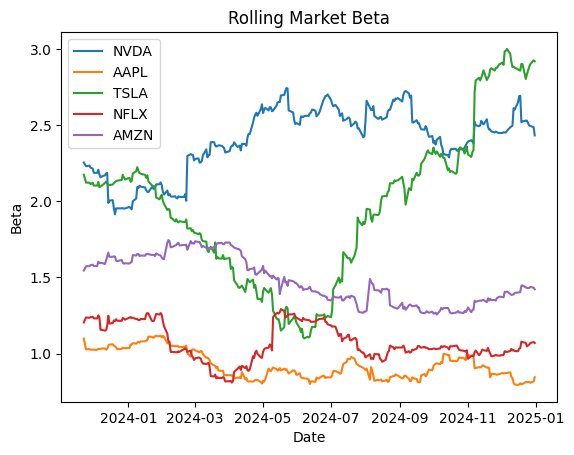

ps. window size is 139 days


In [38]:
# stock = stock_cols[0]  # arbitrary example, possible to change it to a different one
# data = rolling_df[rolling_df["Ticker"] == stock]
# plt.plot(data["Date"], data["Beta_Mkt"])

for stock in stock_cols[:5]: # top 5 most liquid stocks only
    data = rolling_df[rolling_df["Ticker"] == stock]
    plt.plot(data["Date"], data["Beta_Mkt"], label=stock)

plt.title(f"Rolling Market Beta")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
plt.show()
print(f"ps. window size is {window} days")

# Portfolio Risk Decomposition

### Systematic vs Idiosyncratic Risk

In [39]:
equal_weights = np.ones(len(top30_tickers)) / len(top30_tickers)
cov_matrix = returns.cov() * 252
# sns.heatmap(returns.corr(), center=0, cmap="coolwarm");
equal_weights.T @ cov_matrix @ equal_weights

np.float64(0.028895762130760654)

In [40]:
res = results_df.set_index("Ticker").loc[stock_cols]

B = res[["Beta_Mkt", "Beta_SMB", "Beta_HML"]].values
D = np.diag(res["Residual_Var"].values * 252)
Sigma_f = df[["Mkt-RF", "SMB", "HML"]].cov().values * 252 # Calculating on "df", not "factors" -> to have the same time frame
w = equal_weights


var_systematic = w @ B @ Sigma_f @ B.T @ w
var_idiosyncratic = w @ D @ w

var_total = var_systematic + var_idiosyncratic

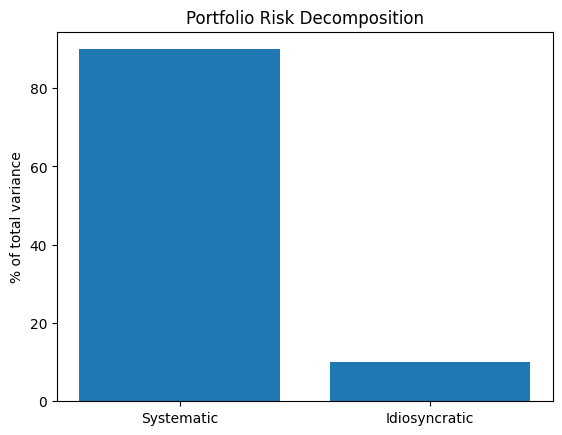

In [41]:
pct_systematic = var_systematic / var_total * 100
pct_idiosyncratic = var_idiosyncratic / var_total * 100

labels = ['Systematic', 'Idiosyncratic']

plt.bar(labels, [pct_systematic,pct_idiosyncratic])
plt.ylabel('% of total variance')
plt.title('Portfolio Risk Decomposition')
plt.show()


### Factor Risk Decomposition

In [42]:
B

array([[ 2.42346513, -0.86604002, -1.17432614],
       [ 0.90518826, -0.07183641, -0.39284759],
       [ 2.15247773,  0.30195462, -0.43709489],
       [ 1.13091185, -0.23345147, -0.60241604],
       [ 1.46457556, -0.23559604, -0.49736928],
       [ 1.14572681, -0.03910558,  1.3999914 ],
       [ 2.09045454, -0.29890329, -0.71978221],
       [ 2.49200692,  0.1251268 , -0.19785659],
       [ 1.2555047 ,  0.08144394,  0.97794218],
       [ 0.19631349, -0.19106878,  0.67937613],
       [ 1.18889269, -0.23032908, -0.44257507],
       [ 1.85830547, -0.04088419,  0.03491104],
       [ 1.19307315, -0.21989568, -0.4334927 ],
       [ 0.78586051, -0.11336387, -0.3830631 ],
       [ 0.24285188,  0.17263587,  0.13802364],
       [ 1.15922627, -0.38771856, -0.44230064],
       [ 2.17716024, -0.38013464, -0.91062919],
       [ 1.83264634, -0.06465357, -0.25734921],
       [ 1.21016749,  0.39182516, -0.22902426],
       [ 0.31521799, -0.04492796, -0.0928785 ],
       [ 1.12592487, -0.05301534,  1.459